In [ ]:
!ls -lh results

In [4]:
import h5py
import numpy as np
import matplotlib.pylab as plt
import os
%matplotlib widget

In [47]:
test_fn = "results2/test_withLabels.h5"
train_fn = "results2/train.h5"
train_fn = "/home/amir/source/MySynthText/results/SynthText.h5"

test_fn_noLabels = "results2/test.h5"

db = h5py.File(train_fn, 'r') 

keys = list(db['data'].keys())

In [48]:
len(keys)

10

In [9]:
im = db['data'][keys[0]][:]

In [10]:
keys

['asphalt_113.jpg_0',
 'bob+dylan_13.jpg_0',
 'bob+dylan_93.jpg_0',
 'chocolate_147.jpg_0',
 'cream_112.jpg_0',
 'desert_16.jpg_0',
 'empty+street_101.jpg_0',
 'places_52.jpg_0',
 'san+diego_22.jpg_0',
 'sandwich_102.jpg_0']

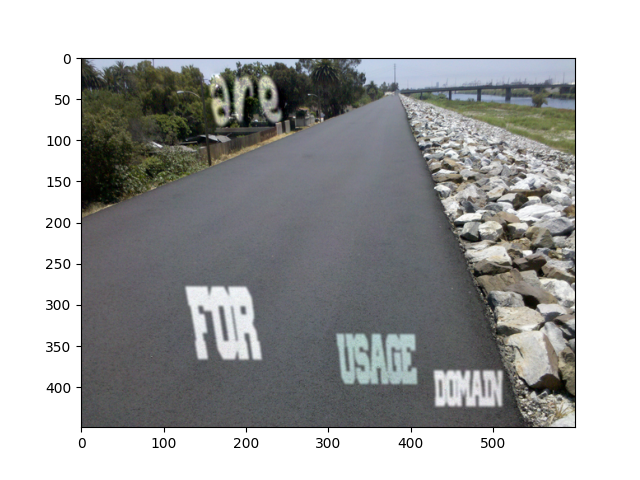

In [11]:
plt.figure()
plt.imshow(im)

In [12]:
# Read fonts.txt into a list
with open('data/fonts/fonts.txt', 'r') as f:
  font_name = [line.strip() for line in f if line.strip()]

print(font_name)
print("num fonts:", len(font_name))

['DEBROSEE', 'Flower Rose Brush', 'FREEDOM', 'Hopkinson', 'Playful Time', 'Skylark', 'Sweet Puppy', 'Ubuntu Mono', 'Wanted M54']
num fonts: 9


In [13]:
color_list = ["r", "b", "y", "k", "m", "w", "g", "r", "b", "y", "k", "m", "w", "g"]

['are' 'domain' 'for' 'Usage']
['Sweet Puppy' 'Wanted M54' 'Wanted M54' 'Wanted M54']
['Sweet Puppy' 'Sweet Puppy' 'Sweet Puppy' 'Wanted M54' 'Wanted M54'
 'Wanted M54' 'Wanted M54' 'Wanted M54' 'Wanted M54' 'Wanted M54'
 'Wanted M54' 'Wanted M54' 'Wanted M54' 'Wanted M54' 'Wanted M54'
 'Wanted M54' 'Wanted M54']


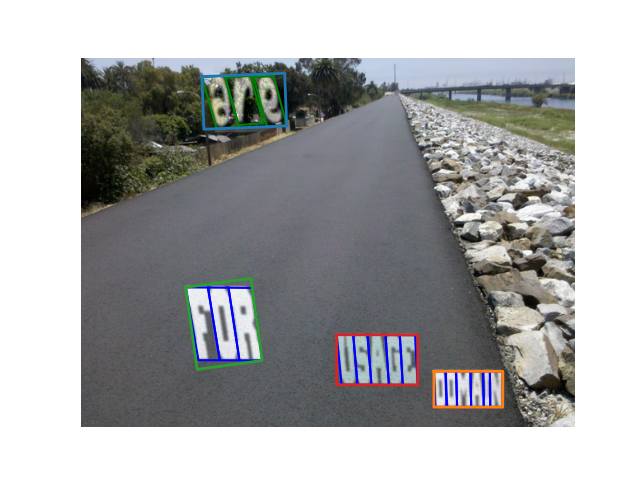

In [14]:
db = h5py.File(train_fn, 'r') 

k = 0
im_data = db["data"][keys[k]]

im = im_data[:]
font_list = im_data.attrs['font']
char_bb = im_data.attrs['charBB']
word_bb = im_data.attrs['wordBB']
text = im_data.attrs['txt']
word_fonts = im_data.attrs['word_font']

nC = char_bb.shape[-1]

plt.figure()
plt.imshow(im)
for b_inx in range(nC):
    c_inx = font_name.index(font_list[b_inx])
    color = color_list[c_inx]
    
    bb = char_bb[:,:,b_inx]
    x = np.append(bb[0,:], bb[0,0])
    y = np.append(bb[1,:], bb[1,0])
    plt.plot(x, y, color)

# plot the word BB
nW = word_bb.shape[-1]
for w_inx in range(nW):
    bb = word_bb[:,:,w_inx]
    x = np.append(bb[0,:], bb[0,0])
    y = np.append(bb[1,:], bb[1,0])
    plt.plot(x, y, lw=2)   

plt.axis('off')
print(text)
print(word_fonts)
print(font_list)

In [15]:
from get_font_paths import get_font_paths_list,read_fonts_txt

In [16]:
read_fonts_txt('/home/amir/source/MySynthText/data/fonts/')

['DEBROSEE',
 'Flower Rose Brush',
 'FREEDOM',
 'Hopkinson',
 'Playful Time',
 'Skylark',
 'Sweet Puppy',
 'Ubuntu Mono',
 'Wanted M54']

pygame 2.6.1 (SDL 2.28.4, Python 3.12.3)
Hello from the pygame community. https://www.pygame.org/contribute.html
(50, 290, 3)
(102, 463, 3)
(33, 338, 3)
(59, 221, 3)
(58, 342, 3)
(63, 422, 3)
(81, 512, 3)
(45, 356, 3)
(51, 435, 3)


/home/amir/miniconda3/envs/cv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


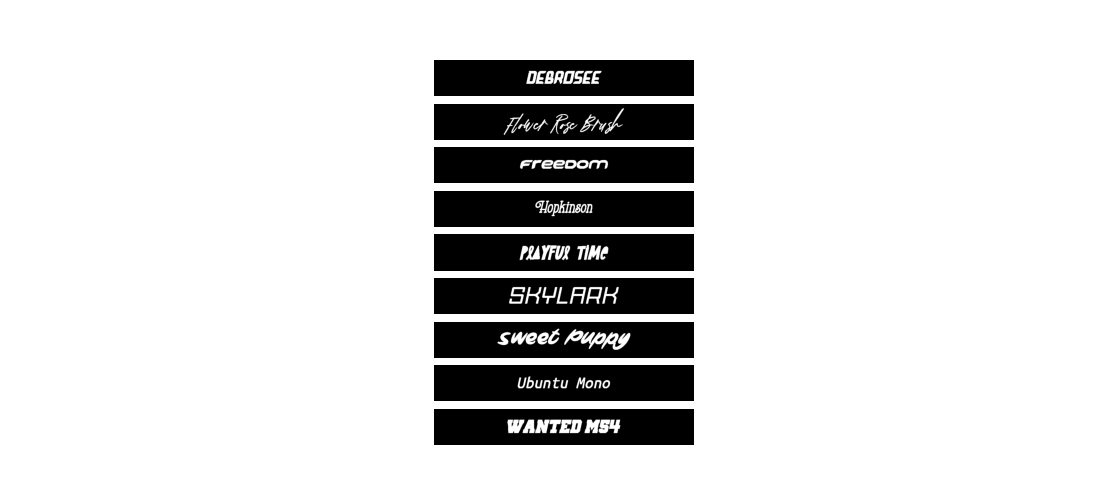

In [17]:
# RENDER_TEXT = "abcdefghijklmnopqrstuvwxyz ABCDEFGHIJKLMNOPQRSTUVWXYZ 0123456789`-=~!@#$%^&*()_+[]\\{}|;':\",./<>?"
RENDER_TEXT = "a b c d e f g h i A B C D E F G H I 0 1 2 3 4 5 6 7 8 9"

RENDER_TEXT = ["always forever", "Skylark", "Sweet puppy", "Ubuntu mono", "Vertigo", "Wanted", "Flower Rose Brush"]

RENDER_TEXT = read_fonts_txt('/home/amir/source/MySynthText/data/fonts/')
import pygame
from pygame.freetype import Font
from pygame import Color

pygame.init()
pygame.freetype.init()

font_name = [b'Skylark',
             b'Sweet Puppy',
             b'Ubuntu Mono',
             b'VertigoFLF',
             b'Wanted M54',
             b'always  forever',
             b'Flower Rose Brush']

files = get_font_paths_list('/home/amir/source/MySynthText/data')

_, axes = plt.subplots(len(files),1, figsize=(11,5))

size = (140, 2500)
size = (140, 1000)

im_list = []
for inx, file in enumerate(files):
    
    font = Font(file, size=64)
    font.strong = True
    font.oblique = True
    font.antialiased = True
    font.origin = True
    font.strength = 0.01
    surface, _ = font.render(
        RENDER_TEXT[inx],
        fgcolor=Color(255, 255, 255, 255),
        bgcolor=Color(0, 0, 0, 0))
    img = pygame.surfarray.array3d(surface)
    img = np.transpose(img, [1, 0, 2])
    print(img.shape)
    
    # pad image to exact target size
    target_h, target_w = size
    pad_h = max(0, target_h - img.shape[0])
    pad_w = max(0, target_w - img.shape[1])
    
    h_before = pad_h // 2
    h_after = pad_h - h_before
    w_before = pad_w // 2
    w_after = pad_w - w_before
    
    img = np.pad(img, ((h_before, h_after), (w_before, w_after), (0, 0)))
    
    # Ensure exact size (crop if needed)
    img = img[:target_h, :target_w, :]
    
    axes[inx].imshow(img)
    axes[inx].set_axis_off()
    
    im_list.append(img)

im = np.concatenate(im_list, axis=0)



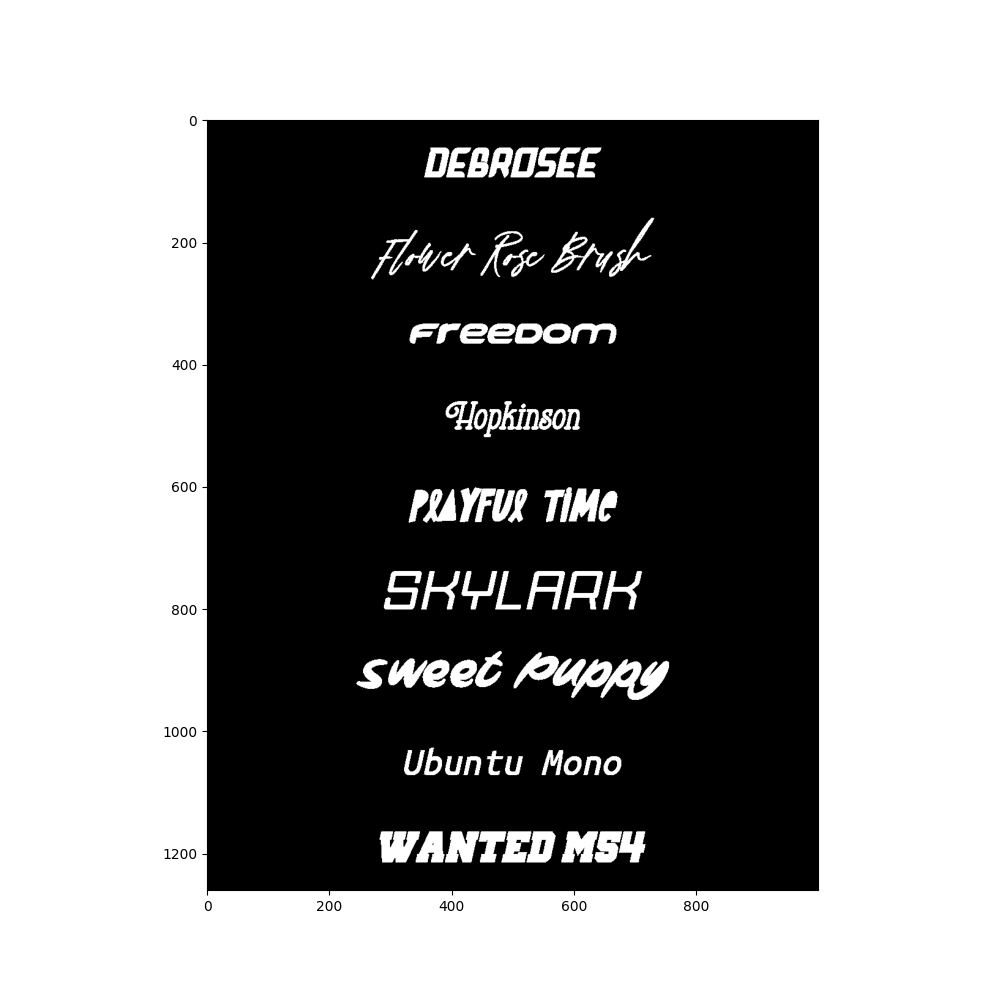

In [18]:
plt.figure(figsize=(10,10))
plt.imshow(im)

# create data sets

In [28]:
train_fn = "/home/amir/source/MySynthText/results/SynthText.h5"
db = h5py.File(train_fn, 'r') 

keys = list(db['data'].keys())
np.random.shuffle(keys)
print("num of images - ", len(keys))

num of images -  10


In [29]:
k = keys[0]
print(db['data'][k].attrs['charBB'].shape)
print(db['data'][k].attrs['font'].shape)
print(db['data'][k].attrs['wordBB'].shape)
print(db['data'][k].attrs['txt'])
print(db['data'][k].attrs['word_font'])

(2, 4, 6)
(6,)
(2, 4, 2)
['GPT' 'for']
['Skylark' 'FREEDOM']


In [20]:
len(''.join([s for s in db['data'][k].attrs['txt'].tolist()]))

17

In [21]:
''.join(str(db['data'][k].attrs['txt'].tolist()))

"['are', 'domain', 'for', 'Usage']"

In [22]:
train_file = 'results/train.h5'
test_with_labels = 'results/test_wl.h5'
test_no_labels = 'results/test.h5'

In [33]:
train_db = h5py.File(train_file, 'w')
test_w_db = h5py.File(test_with_labels, 'w')
test_n_db = h5py.File(test_no_labels, 'w')

In [34]:
train_db.create_group('/data')
test_w_db.create_group('/data')
test_n_db.create_group('/data')

<HDF5 group "/data" (0 members)>

In [35]:
for inx, k in enumerate(keys):
    print(inx, '/', len(keys))
    im = db['data'][k][:]
    if inx < len(keys)/2:
        print("test data:")
        test_w_db['data'].create_dataset(k, data=im)
        test_w_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        test_w_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        test_w_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
        test_w_db['data'][k].attrs['font'] = db['data'][k].attrs['font']
        test_w_db['data'][k].attrs['word_font'] = db['data'][k].attrs['word_font']

        test_n_db['data'].create_dataset(k, data=im)
        # test_n_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        test_n_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        test_n_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
#         test_n_db['data'][k].attrs['font'] = db['data'][k].attrs['font']

    else:
        print("train data:")
        train_db['data'].create_dataset(k, data=im)
        if np.random.rand() < 0.5:
            train_db['data'][k].attrs['charBB'] = db['data'][k].attrs['charBB']
        train_db['data'][k].attrs['wordBB'] = db['data'][k].attrs['wordBB']        
        train_db['data'][k].attrs['txt'] = db['data'][k].attrs['txt']
        train_db['data'][k].attrs['font'] = db['data'][k].attrs['font']
        train_db['data'][k].attrs['word_font'] = db['data'][k].attrs['word_font']

0 / 10
test data:
1 / 10
test data:
2 / 10
test data:
3 / 10
test data:
4 / 10
test data:
5 / 10
train data:
6 / 10
train data:
7 / 10
train data:
8 / 10
train data:
9 / 10
train data:


In [36]:
train_db.close()
test_w_db.close()
test_n_db.close()

In [46]:
# check dataset:

db = h5py.File(test_no_labels, 'r') 

keys = list(db['data'].keys())
for k in keys:
    im = db['data'][k][:]
    print("image shape: ", im.shape)
    try:
        print(db['data'][k].attrs['charBB'].shape)
    except:
        print("no char bb")
    try:
        print(db['data'][k].attrs['font'])
        print(db['data'][k].attrs['word_font'])
    except:
        print("no fonts")
    print(db['data'][k].attrs['wordBB'].shape)
    print(db['data'][k].attrs['txt'])
    

image shape:  (375, 600, 3)
no char bb
no fonts
(2, 4, 6)
['and' 'name' 'correct' 'acoustics' 'content' 'impact']
image shape:  (267, 600, 3)
no char bb
no fonts
(2, 4, 5)
['potential' 'conveying' 'help' 'date' 'and']
image shape:  (600, 413, 3)
no char bb
no fonts
(2, 4, 1)
['the']
image shape:  (376, 600, 3)
no char bb
no fonts
(2, 4, 2)
['GPT' 'for']
image shape:  (450, 600, 3)
no char bb
no fonts
(2, 4, 5)
['Sec' 'the' 'risks' 'explain' 'GPT']


# sample submission file

In [ ]:

fix_db.close()

In [ ]:
train_fn = "results2/train.h5"

db = h5py.File(train_fn, 'r')
keys = list(db['data'].keys())
len(keys)


[Demo 1] Basic distribution:
  Font 0: 40%
  Font 1: 30%
  Rest (7 fonts): 3% each


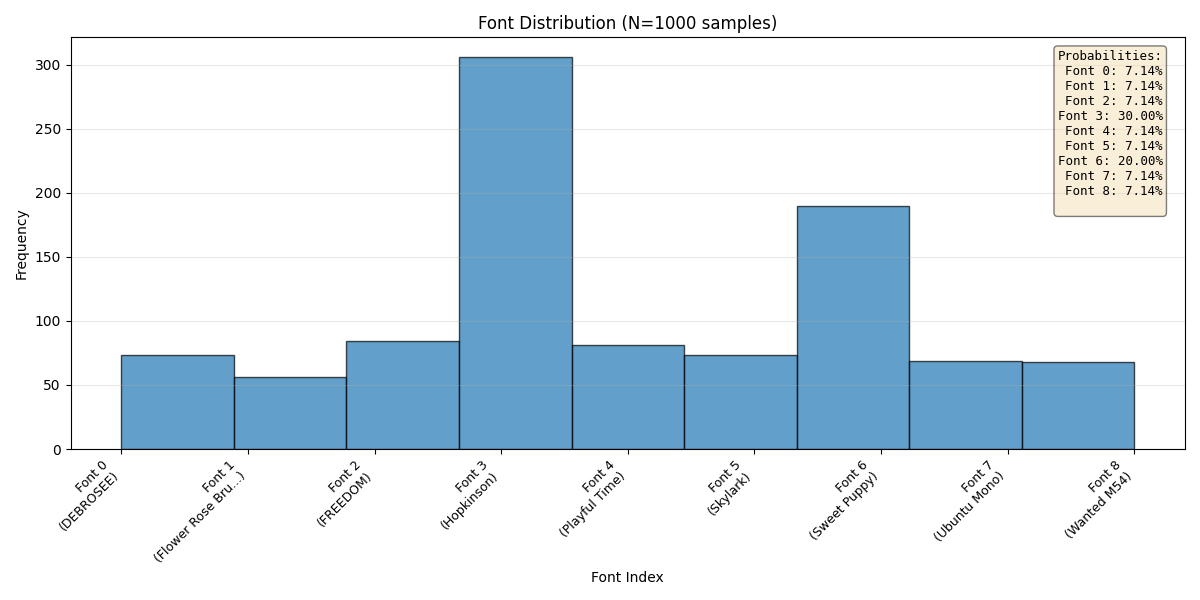


Sampled 1000 fonts from distribution:

Theoretical Probabilities:
  Font 0 (DEBROSEE): 0.0714 (7.14%)
  Font 1 (Flower Rose Brush): 0.0714 (7.14%)
  Font 2 (FREEDOM): 0.0714 (7.14%)
  Font 3 (Hopkinson): 0.3000 (30.00%)
  Font 4 (Playful Time): 0.0714 (7.14%)
  Font 5 (Skylark): 0.0714 (7.14%)
  Font 6 (Sweet Puppy): 0.2000 (20.00%)
  Font 7 (Ubuntu Mono): 0.0714 (7.14%)
  Font 8 (Wanted M54): 0.0714 (7.14%)

Actual Sample Counts:
  Font 0 (DEBROSEE): 73 samples (7.30%)
  Font 1 (Flower Rose Brush): 56 samples (5.60%)
  Font 2 (FREEDOM): 84 samples (8.40%)
  Font 3 (Hopkinson): 306 samples (30.60%)
  Font 4 (Playful Time): 81 samples (8.10%)
  Font 5 (Skylark): 73 samples (7.30%)
  Font 6 (Sweet Puppy): 190 samples (19.00%)
  Font 7 (Ubuntu Mono): 69 samples (6.90%)
  Font 8 (Wanted M54): 68 samples (6.80%)



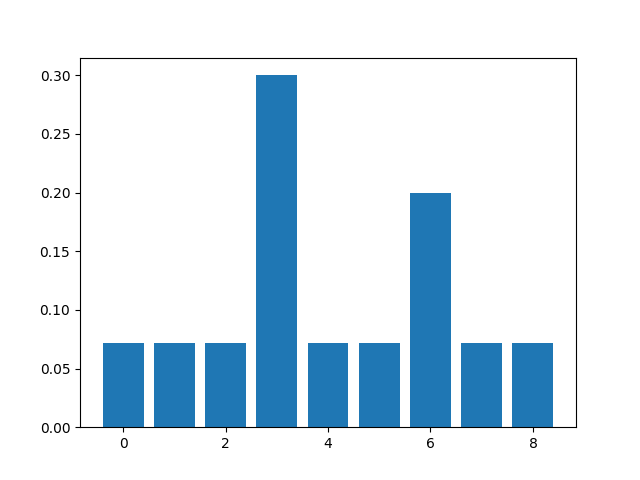

In [63]:
class Fonts():
    def __init__(self, font_list):
        self.fonts = font_list
        
    def sample_font_weighted(self, high_prob_indices=[0, 1], high_probs=[0.4, 0.3]):
        """
        Sample a font with custom distribution.
        
        Args:
          high_prob_indices: List of indices with higher probability
          high_probs: List of probabilities for each high-prob font (must match length of high_prob_indices)
        """
        n_fonts = len(self.fonts)
        n_high = len(high_prob_indices)
        
        # Validate inputs
        if len(high_probs) != n_high:
          raise ValueError("high_probs must have same length as high_prob_indices")
        
        # Calculate remaining probability
        remaining_prob = 1.0 - sum(high_probs)
        n_remaining = n_fonts - n_high
        
        # Base probability for other fonts
        base_prob = remaining_prob / n_remaining if n_remaining > 0 else 0
        
        # Create probability array
        probs = np.ones(n_fonts) * base_prob
        
        # Set custom high probabilities
        for idx, prob in zip(high_prob_indices, high_probs):
          probs[idx] = prob
        
        # Normalize to ensure sum = 1.0
        probs = probs / np.sum(probs)
        
        # Sample one font
        font_idx = np.random.choice(n_fonts, p=probs)
        return self.fonts[font_idx], probs
        
    def sample_and_plot(self, n_samples=1000, high_prob_indices=[0, 1], high_probs=[0.4, 0.3]):
        """
        Sample N times from the font distribution and plot histogram.

        Args:
            n_samples: Number of samples to draw
            high_prob_indices: Indices of high-probability fonts
            high_probs: Probabilities for high-prob fonts
        """
        # Create probability distribution
        n_fonts = len(self.fonts)
        n_high = len(high_prob_indices)

        remaining_prob = 1.0 - sum(high_probs)
        n_remaining = n_fonts - n_high
        base_prob = remaining_prob / n_remaining if n_remaining > 0 else 0

        probs = np.ones(n_fonts) * base_prob
        for idx, prob in zip(high_prob_indices, high_probs):
            probs[idx] = prob
        probs = probs / np.sum(probs)

        # Sample N times
        samples = np.random.choice(n_fonts, size=n_samples, p=probs)

        # Plot histogram
        plt.figure(figsize=(12, 6))
        plt.hist(samples, bins=n_fonts, edgecolor='black', alpha=0.7)
        plt.xlabel('Font Index')
        plt.ylabel('Frequency')
        plt.title(f'Font Distribution (N={n_samples} samples)')

        # Add font names as labels
        font_labels = [f'Font {i}\n({self.fonts[i][:15]}...)' if len(self.fonts[i]) > 15
                       else f'Font {i}\n({self.fonts[i]})'
                       for i in range(n_fonts)]
        plt.xticks(range(n_fonts), font_labels, rotation=45, ha='right', fontsize=9)

        # Add grid
        plt.grid(axis='y', alpha=0.3)

        # Add legend with probabilities
        legend_text = 'Probabilities:\n'
        for i, p in enumerate(probs):
            legend_text += f'Font {i}: {p:.2%}\n'
        plt.text(0.98, 0.97, legend_text, transform=plt.gca().transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                 fontsize=9, family='monospace')

        plt.tight_layout()
        plt.show()

        # Print statistics
        print(f"\n{'='*60}")
        print(f"Sampled {n_samples} fonts from distribution:")
        print(f"{'='*60}")
        print(f"\nTheoretical Probabilities:")
        for i, p in enumerate(probs):
            print(f"  Font {i} ({self.fonts[i]}): {p:.4f} ({p*100:.2f}%)")

        print(f"\nActual Sample Counts:")
        unique, counts = np.unique(samples, return_counts=True)
        for font_idx, count in zip(unique, counts):
            percentage = count / n_samples * 100
            print(f"  Font {font_idx} ({self.fonts[font_idx]}): {count} samples ({percentage:.2f}%)")

        print(f"{'='*60}\n")

# Example with different distributions
font_demo = Fonts(read_fonts_txt('/home/amir/source/MySynthText/data/fonts/'))

# 40% each for fonts 0 and 1, 10% for the rest (5 fonts)
font, probs = font_demo.sample_font_weighted(high_prob_indices=[2, 5], high_probs=[0.3, 0.2])

plt.figure()
plt.bar(range(9), probs)
# # 50% each for fonts 2 and 5, 11.11% for the rest (7 fonts)
# font = self.sample_font_weighted(high_prob_indices=[2, 5], high_prob=0.5)

# # 30% each for fonts 0, 1, and 3, rest share 10%
# font = self.sample_font_weighted(high_prob_indices=[0, 1, 3], high_prob=0.3)

# Demo 1: Basic usage - Font 0 (40%), Font 1 (30%), rest equal
print("\n[Demo 1] Basic distribution:")
print("  Font 0: 40%")
print("  Font 1: 30%")
print("  Rest (7 fonts): 3% each")
font_demo.sample_and_plot(
    n_samples=1000,
    high_prob_indices=[3, 6],
    high_probs=[0.3, 0.2]
)


In [62]:
font

'Flower Rose Brush'